#Customer Churn Analysis

##STEP 1: Import Libraries & Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_excel("Customer_Churn_Data_Large.xlsx")

# Preview data
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


#STEP 2: Understand the Data

In [2]:
# Basic info
df.info()

# Statistical summary
df.describe()

# Check shape
df.shape

# Check column names
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel'], dtype='object')

#STEP 3: Handle Missing Values

In [3]:
# Check missing values
df.isnull().sum()

# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

,0
CustomerID,0.0
Age,0.0
Gender,0.0
MaritalStatus,0.0
IncomeLevel,0.0


##🔧 Handling strategy:

In [5]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2010/1587133217.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


#STEP 4: Exploratory Data Analysis (EDA)

##4.1 Target Variable Distribution

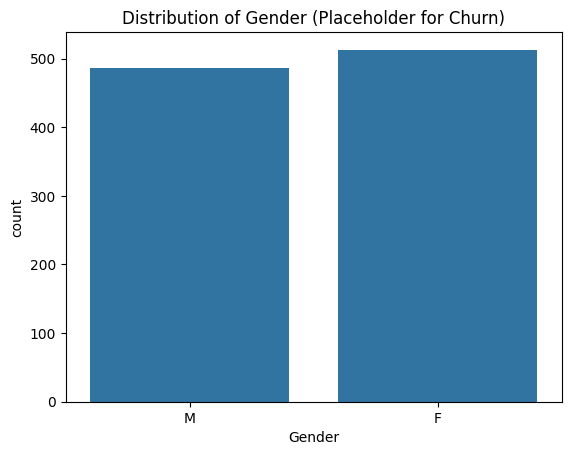

In [7]:
sns.countplot(x='Gender', data=df)
plt.title("Distribution of Gender (Placeholder for Churn)")
plt.show()

##4.2 Numerical Features Distribution

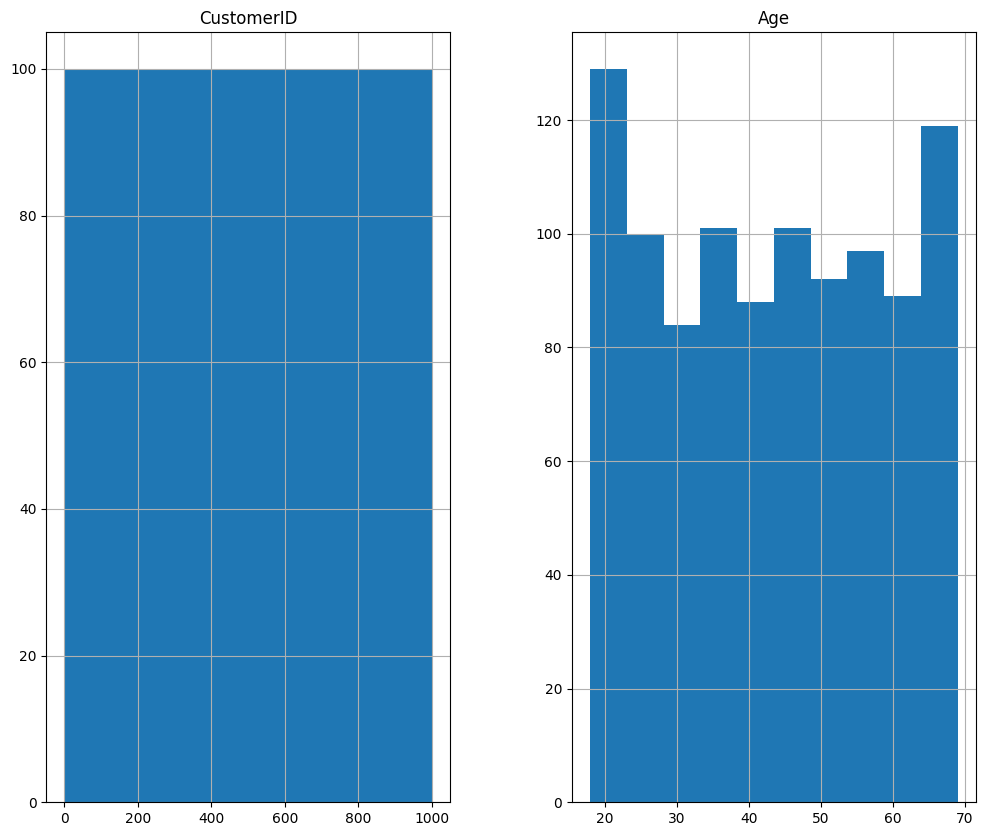

In [8]:
df.hist(figsize=(12,10))
plt.show()

##4.3 Correlation Heatmap

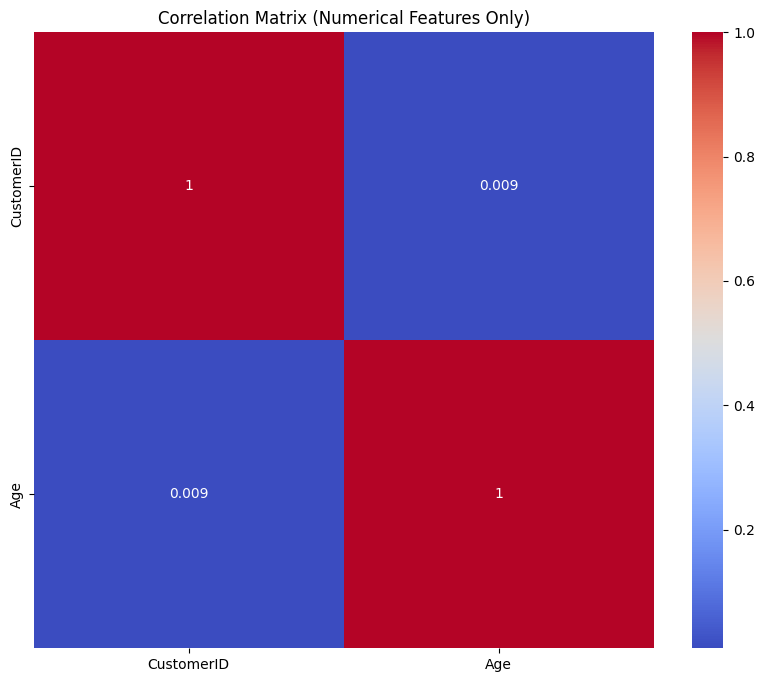

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features Only)")
plt.show()

##4.4 Categorical vs Churn

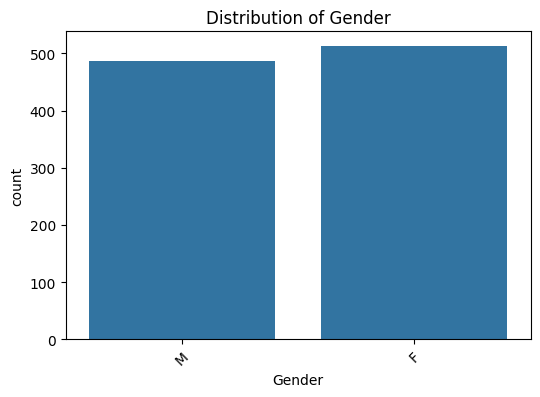

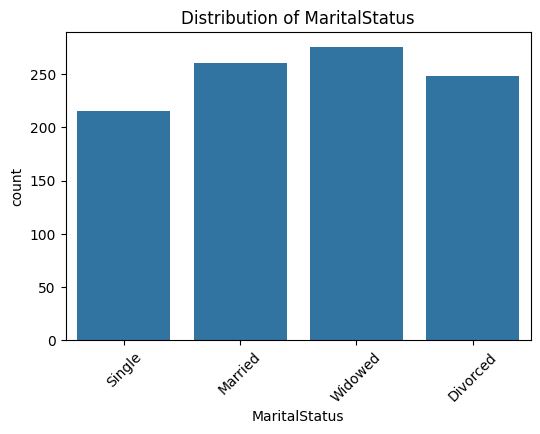

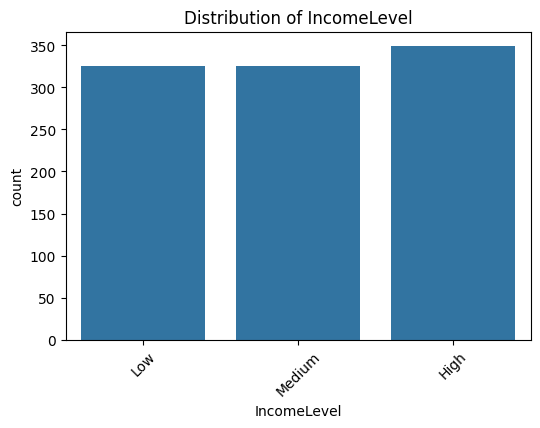

In [12]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

##4.5 Boxplots (Outlier Detection)

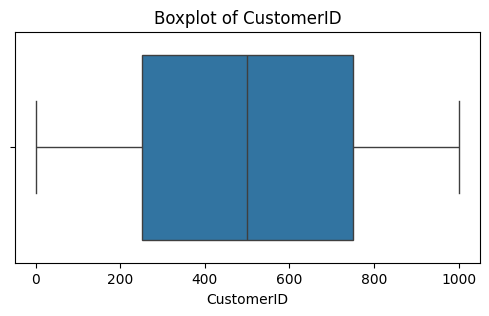

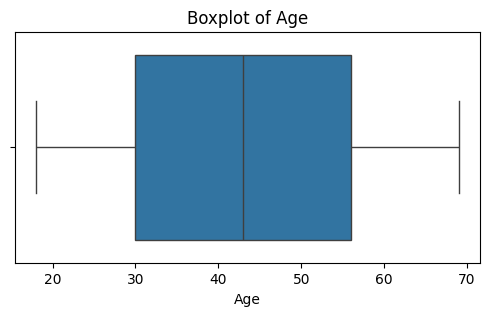

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

#STEP 5: Outlier Treatment

In [14]:
# IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
               np.where(df[col] > upper, upper, df[col]))

#STEP 6: Encode Categorical Variables

In [15]:
# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

#STEP 7: Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

#STEP 8: Final Clean Dataset

In [17]:
# Final check
df.head()

# Save cleaned dataset
df.to_csv("cleaned_customer_churn.csv", index=False)